In [253]:
import jax
from astropy.table import Table
import numpy as np
import jax.numpy as jnp
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
from dustmaps.config import config
import dustmaps.edenhofer2023
import healpy as hp
import astropy as ap
from astropy.coordinates import SkyCoord
from dustmaps.edenhofer2023 import Edenhofer2023Query
import jax.random as jr
from astropy.io import fits
from Better_HMC import HMCSampler 
import jax.scipy.special as jss
import arviz as az

gc_builtin = SkyCoord(0*u.deg, 0*u.deg, frame='galactic').icrs
t = Table.read("gc_sightline.fits")   # add the path if the notebook runs elsewhere,
                                       # e.g. "Gaia XP/gc_sightline.fits"
star_coords = SkyCoord(np.asarray(t["ra"])*u.deg, np.asarray(t["dec"])*u.deg)
t["sep_gc_deg"] = star_coords.separation(gc_builtin).deg


plx_np = t["parallax"]              # parallax measurements (mas)
plx = jnp.asarray(np.asarray(plx_np).astype(np.float32))
plx_err_np = t["parallax_err"]         # their uncertainties (mas)
plx_err = jnp.asarray(np.asarray(plx_err_np).astype(np.float32))
ext_np  = t["ext"]                  # extinction
ext = jnp.asarray(np.asarray(ext_np).astype(np.float32))
ext_err_np = t["ext_err"]
ext_err = jnp.asarray(np.asarray(ext_err_np).astype(np.float32))
sep_np = t["sep_gc_deg"]
separation = jnp.asarray(np.asarray(sep_np).astype(np.float32))
print(t.info())

with fits.open("mean_and_std_healpix.fits") as hdul:
    hdul.info()
    print(hdul['MEAN'].header['ORDERING'])
    print(hdul['STD.'].header['ORDERING'])
    galactic_center_healpix = hp.pixelfunc.ang2pix(256, theta = 0.0, phi = 0.0, nest = True, lonlat = True)
    mean_along_center = jnp.asarray(hdul["MEAN"].data[:, galactic_center_healpix].astype(np.float32))
    std_along_center  = jnp.asarray(hdul["STD."].data[:, galactic_center_healpix].astype(np.float32))
    radial_centers    = jnp.asarray(hdul["RADIAL PIXEL CENTERS"].data.field(0),    dtype=jnp.float32)
    radial_boundaries = jnp.asarray(hdul["RADIAL PIXEL BOUNDARIES"].data.field(0), dtype=jnp.float32)
    distance_gaps = np.diff(radial_boundaries)


assert mean_along_center.shape == distance_gaps.shape


<Table length=54602>
     name       dtype 
-------------- -------
gdr3_source_id   int64
            ra float32
           dec float32
      parallax float32
  parallax_err float32
           ext float32
       ext_err float32
        teff_K float32
           feh float32
          logg float32
  plx_over_err float32
    sep_gc_deg float64
None
Filename: mean_and_std_healpix.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   ()      
  1  MEAN          1 ImageHDU        19   (786432, 516)   float32   
  2  STD.          1 ImageHDU        19   (786432, 516)   float32   
  3  RADIAL PIXEL CENTERS    1 BinTableHDU     20   516R x 1C   [E]   
  4  RADIAL PIXEL BOUNDARIES    1 BinTableHDU     20   517R x 1C   [E]   
  5  MEAN OF INTEGRATED INNER 68.8 PC    1 ImageHDU        16   (786432,)   float32   
  6  STD. OF INTEGRATED INNER 68.8 PC    1 ImageHDU        16   (786432,)   float32   
NEST
NEST


In [254]:
def mask_cov_square(cov, keep_first, keep_last):
    n = cov.shape[0]
    idx  = np.arange(n)
    keep = (idx < keep_first) | (idx >= n - keep_last)
    M = np.eye(n)                              # identity baseline
    M[np.ix_(keep, keep)] = cov[np.ix_(keep, keep)]
    return M

def mask_cov_diagonal(cov, keep_first, keep_last):
    cov_diag = jnp.diagonal(cov)
    n = cov_diag.size
    M_diag = np.ones(n)
    M_diag[:keep_first] = cov_diag[:keep_first]
    M_diag[-keep_last:] = cov_diag[-keep_last:]
    return jnp.diag(cov_diag)


num_dimensions = 500
num_fourier_dimensions = 700
left_distance_padding = 40
right_distance_padding = 200
min_distance = radial_boundaries[0] - left_distance_padding
max_distance = radial_boundaries[radial_boundaries.size - 1] + right_distance_padding
dx = (max_distance - min_distance)/(num_dimensions - 1)
# This is the analouge of fixed_points_linspace
dust_x_linspace = jnp.arange(num_dimensions)*dx + min_distance
fourier_length = dx*(num_fourier_dimensions - 1)
num_fitting_params = 3
omegas = 2*jnp.pi*jnp.fft.fftfreq(num_fourier_dimensions, d = dx)
error_bars_on_data = 0.025

cumulative_integrated_dust = jnp.concatenate(
    [jnp.array([0.0]), jnp.cumsum(mean_along_center * distance_gaps)]
)

num_overall_steps = 200
burn_in = 0
num_integration_steps = 500
step_size = 0.004

#inv_mass_matrix = jnp.eye(num_fourier_dimensions + num_fitting_params)
#inv_mass_matrix = inv_mass_matrix.at[1, 1].set(1)
inv_mass_matrix = mask_cov_square(np.load("cov_matrix_Gaia_XP_fitting.npy"), 30, 30)





initial_logvar = 4.0
initial_lognu = 0
initial_offset = -7.6

logvar_prior_mean = initial_logvar
lognu_prior_mean = 0.0
offset_prior_mean = initial_offset

fixed_logscale = jnp.log(2*fourier_length)

normalization_factor = num_fourier_dimensions/jnp.sqrt(fourier_length)

doing_burn_in = False


840


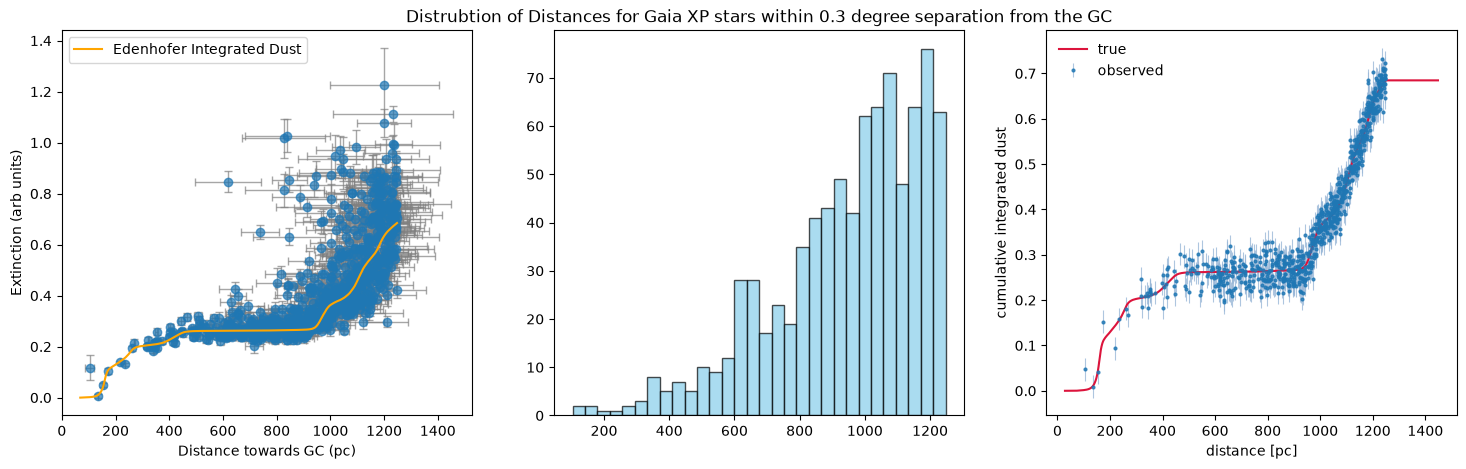

In [255]:
fig, axes = plt.subplots(1, 3, figsize = (18, 5))
dist_err = 1000*(plx**(-2))*plx_err
distances_psc = 1000/plx
mask = (distances_psc > 0) & (distances_psc < radial_boundaries[radial_boundaries.size - 1]) & (separation < 0.3) & (t["plx_over_err"] > 5)
axes[0].errorbar(distances_psc[mask], ext[mask],
             yerr=ext_err[mask],      # vertical error bars
             xerr=dist_err[mask],     # horizontal error bars (optional)
             fmt='o',                 # marker style, no connecting line
             ecolor='gray',           # error bar color
             elinewidth=1,
             capsize=3,               # little caps on the ends
             alpha=0.7)
axes[0].plot(radial_boundaries, cumulative_integrated_dust, color="orange", alpha=1, zorder=5, label="Edenhofer Integrated Dust")
axes[0].legend()
axes[0].set_xlabel("Distance towards GC (pc)")
axes[0].set_ylabel("Extinction (arb units)")

axes[1].hist(
    distances_psc[mask], bins=30, color="skyblue", edgecolor="black", alpha=0.7
)
axes[1].set_title("Distrubtion of Distances for Gaia XP stars within 0.3 degree separation from the GC")

rng = jr.PRNGKey(0)
rng, k1, k2 = jr.split(rng, 3)
x_obs = distances_psc[mask]
num_data = distances_psc[mask].size
y_obs_true = jnp.interp(x_obs, radial_boundaries, cumulative_integrated_dust)
yerr = jnp.ones(shape = (num_data, ))*error_bars_on_data
y_obs_err = jr.normal(k1, shape = (num_data,))*yerr
y_obs = y_obs_true + y_obs_err
inv_cov_data_matrix = jnp.linalg.inv(jnp.diag(yerr**2))

axes[2].errorbar(x_obs, y_obs, yerr = yerr, fmt='.', markersize=4, ecolor='#9ab8d8', elinewidth=0.8, capsize=0, alpha=0.8, label='observed')
axes[2].plot(dust_x_linspace, jnp.interp(dust_x_linspace, radial_boundaries, cumulative_integrated_dust), color='crimson', lw=1.5, label='true')
axes[2].set_xlabel('distance [pc]')
axes[2].set_ylabel('cumulative integrated dust')
axes[2].legend(frameon=False)
print(num_data)

In [256]:

def hartley(x):
    fft = jnp.fft.fft(x)
    return jnp.real(fft) - jnp.imag(fft)

def cumulative_trapezoid(y, dx):
    seg = dx * (y[:-1] + y[1:]) / 2.0            # area of each trapezoid segment
    return jnp.concatenate([jnp.zeros(1, y.dtype), jnp.cumsum(seg)])


def exponentiated_integrated_density(logdensity):
    density = jnp.exp(logdensity)
    return cumulative_trapezoid(density, dx)

def response_function(xi, inference_params, offset):
    field = fft_field_hartley(xi, inference_params) + offset
    exp_int_field = exponentiated_integrated_density(field)
    return jnp.interp(x_obs, dust_x_linspace, exp_int_field)

def general_matern_spectral_density(omega, inference_params, jitter = 1e-6):
        logvar, lognu = inference_params
        #logvar, lognu = 5.0, jnp.log(0.475)
        logscale = fixed_logscale
        nu = jnp.exp(lognu)
        log_ratio = jss.gammaln(nu + 0.5) - jss.gammaln(nu)
        r = jnp.square(omega) * jnp.exp(2 * logscale - jnp.log(2.0) - lognu)
        logdensity = logvar + log_ratio - 0.5*jnp.log(2*nu) + logscale - (nu + 0.5)*jnp.log1p(r)
        result = 2*jnp.sqrt(jnp.pi)*jnp.exp(logdensity)
        return jnp.where(omega > 0, result, result * (1.0 + jitter))

def matern_magnitude(omegas, inference_params):
     return jnp.sqrt(general_matern_spectral_density(omegas, inference_params))


def fft_field_hartley(noise, inference_params):
    size = noise.shape[0]
    raw_average_amplitude_data = matern_magnitude(omegas, inference_params)
    H = noise * raw_average_amplitude_data          # elementwise, whole array, in order
    y_data = (hartley(H) / size) * normalization_factor 
    return y_data[0:num_dimensions]



def logvarprior(logvar):
    return -0.5*(logvar - logvar_prior_mean)**2
def lognuprior(lognu):
    return -0.5*(lognu - lognu_prior_mean)**2
def logoffsetprior(offset):
    return -0.5*(offset - offset_prior_mean)**2
def negative_logdensity(x):
    logvar = x[0]
    lognu = x[1]
    offset = x[2]
    xi = x[3:]
    inference_params = (logvar, lognu)
    negative_log_p_s = -logvarprior(logvar) - lognuprior(lognu) - logoffsetprior(offset) + 0.5*xi.T @ xi
    res = y_obs - response_function(xi, inference_params, offset)
    negative_log_p_d_given_s = 0.5*res.T @ inv_cov_data_matrix @ res
    return negative_log_p_s + negative_log_p_d_given_s


if(doing_burn_in):
    initial_coordinates = jnp.zeros(num_fourier_dimensions + num_fitting_params) 
    initial_coordinates = initial_coordinates.at[0].set(initial_logvar)
    initial_coordinates = initial_coordinates.at[1].set(initial_lognu)
    initial_coordinates = initial_coordinates.at[2].set(initial_offset)
else:
    initial_coordinates = jnp.asarray(np.load("last_position_Gaia_XP_fitting.npy"))

num_good_samples = num_overall_steps - burn_in
time_arr = jnp.arange(num_good_samples)


Text(0.5, 1.0, 'Diagonal Covariance')

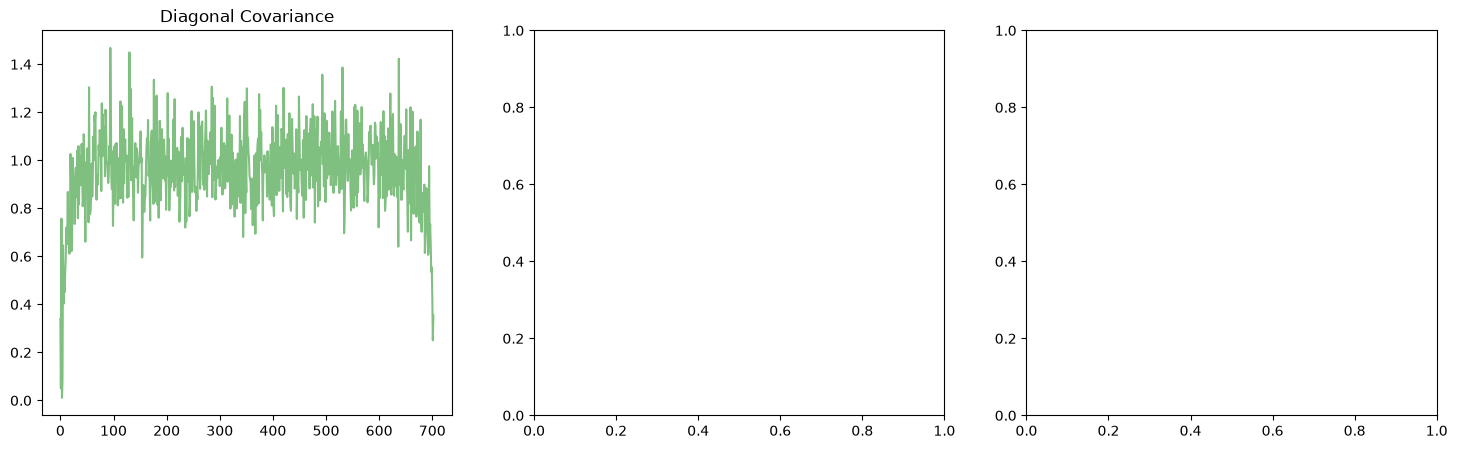

In [257]:
sampler = HMCSampler(
    negative_logdensity= negative_logdensity,
    num_integration_steps=num_integration_steps,
    step_size=step_size,
    inv_mass_matrix = inv_mass_matrix,
    alpha=1.0
)

rng = jr.PRNGKey(5)

overall_data_arr, overall_momentum_arr, accept_prob_arr = sampler.sample(
    start_position=initial_coordinates, 
    num_samples=num_overall_steps,
    burn_in = burn_in,
    rng_key=rng
)

logvars = overall_data_arr[:, 0]
lognus = overall_data_arr[:, 1]
offsets = overall_data_arr[:, 2]
overall_position_arr = overall_data_arr[:, 3:]  
logscales = jnp.zeros_like(logvars)
inference_params = (logvars, lognus)

overall_position_arr_raw = jax.vmap(fft_field_hartley, in_axes=(0, 0))(
    overall_position_arr, inference_params
) 
overall_position_arr_raw = overall_position_arr_raw + offsets[:, None]
overall_position_arr_exp = jax.vmap(exponentiated_integrated_density, in_axes=(0))(
    overall_position_arr_raw
)
overall_position_arr_raw = overall_position_arr_raw[:, 0:num_dimensions]
overall_position_arr_exp = overall_position_arr_exp[:, 0:num_dimensions]

mean_position_raw = overall_position_arr_raw.sum(axis=0)/num_good_samples
mean_position_exp = overall_position_arr_exp.sum(axis=0)/num_good_samples
vars = jnp.exp(logvars)
scales = jnp.exp(logscales)
nus = jnp.exp(lognus)
cov= jnp.cov(overall_data_arr, rowvar = False)
fig, axes = plt.subplots(1, 3, figsize = (18, 5))
timegrid = jnp.arange(num_fourier_dimensions + num_fitting_params)
axes[0].plot(timegrid, jnp.diagonal(cov), color = "Green", alpha = 0.5)
axes[0].set_title("Diagonal Covariance")
#np.save('cov_matrix_Gaia_XP_fitting.npy', np.asarray(cov))


200
200
ESS for Variance parameter (index 0): 35.313313540073814
ESS for Nu parameter (index 1): 41.70672925462037
ESS for 29th parameter (index 30): 249.37985158535417
Num integration steps: 500 Step Size: 0.004
Average acceptance probability (acceptance rate) is: 0.8618976473808289
Num dimensions: 500 Num data: 840 Total length: 1419.4813232421875 Noise on each point: 0.025 Num HMC trials: 200
(200, 500)
Error bars on data: 0.025
Logvar prior mean: 4.0 Lognu prior mean: 0.0 Offset prior mean -7.6 Initial logvar/lognu/offset values: 4.0, 0, -7.6
Average chi_2 statistic based on the prior: 0.9621667861938477
Average chi_2 statistic based on the data per data point: 1.0898948907852173


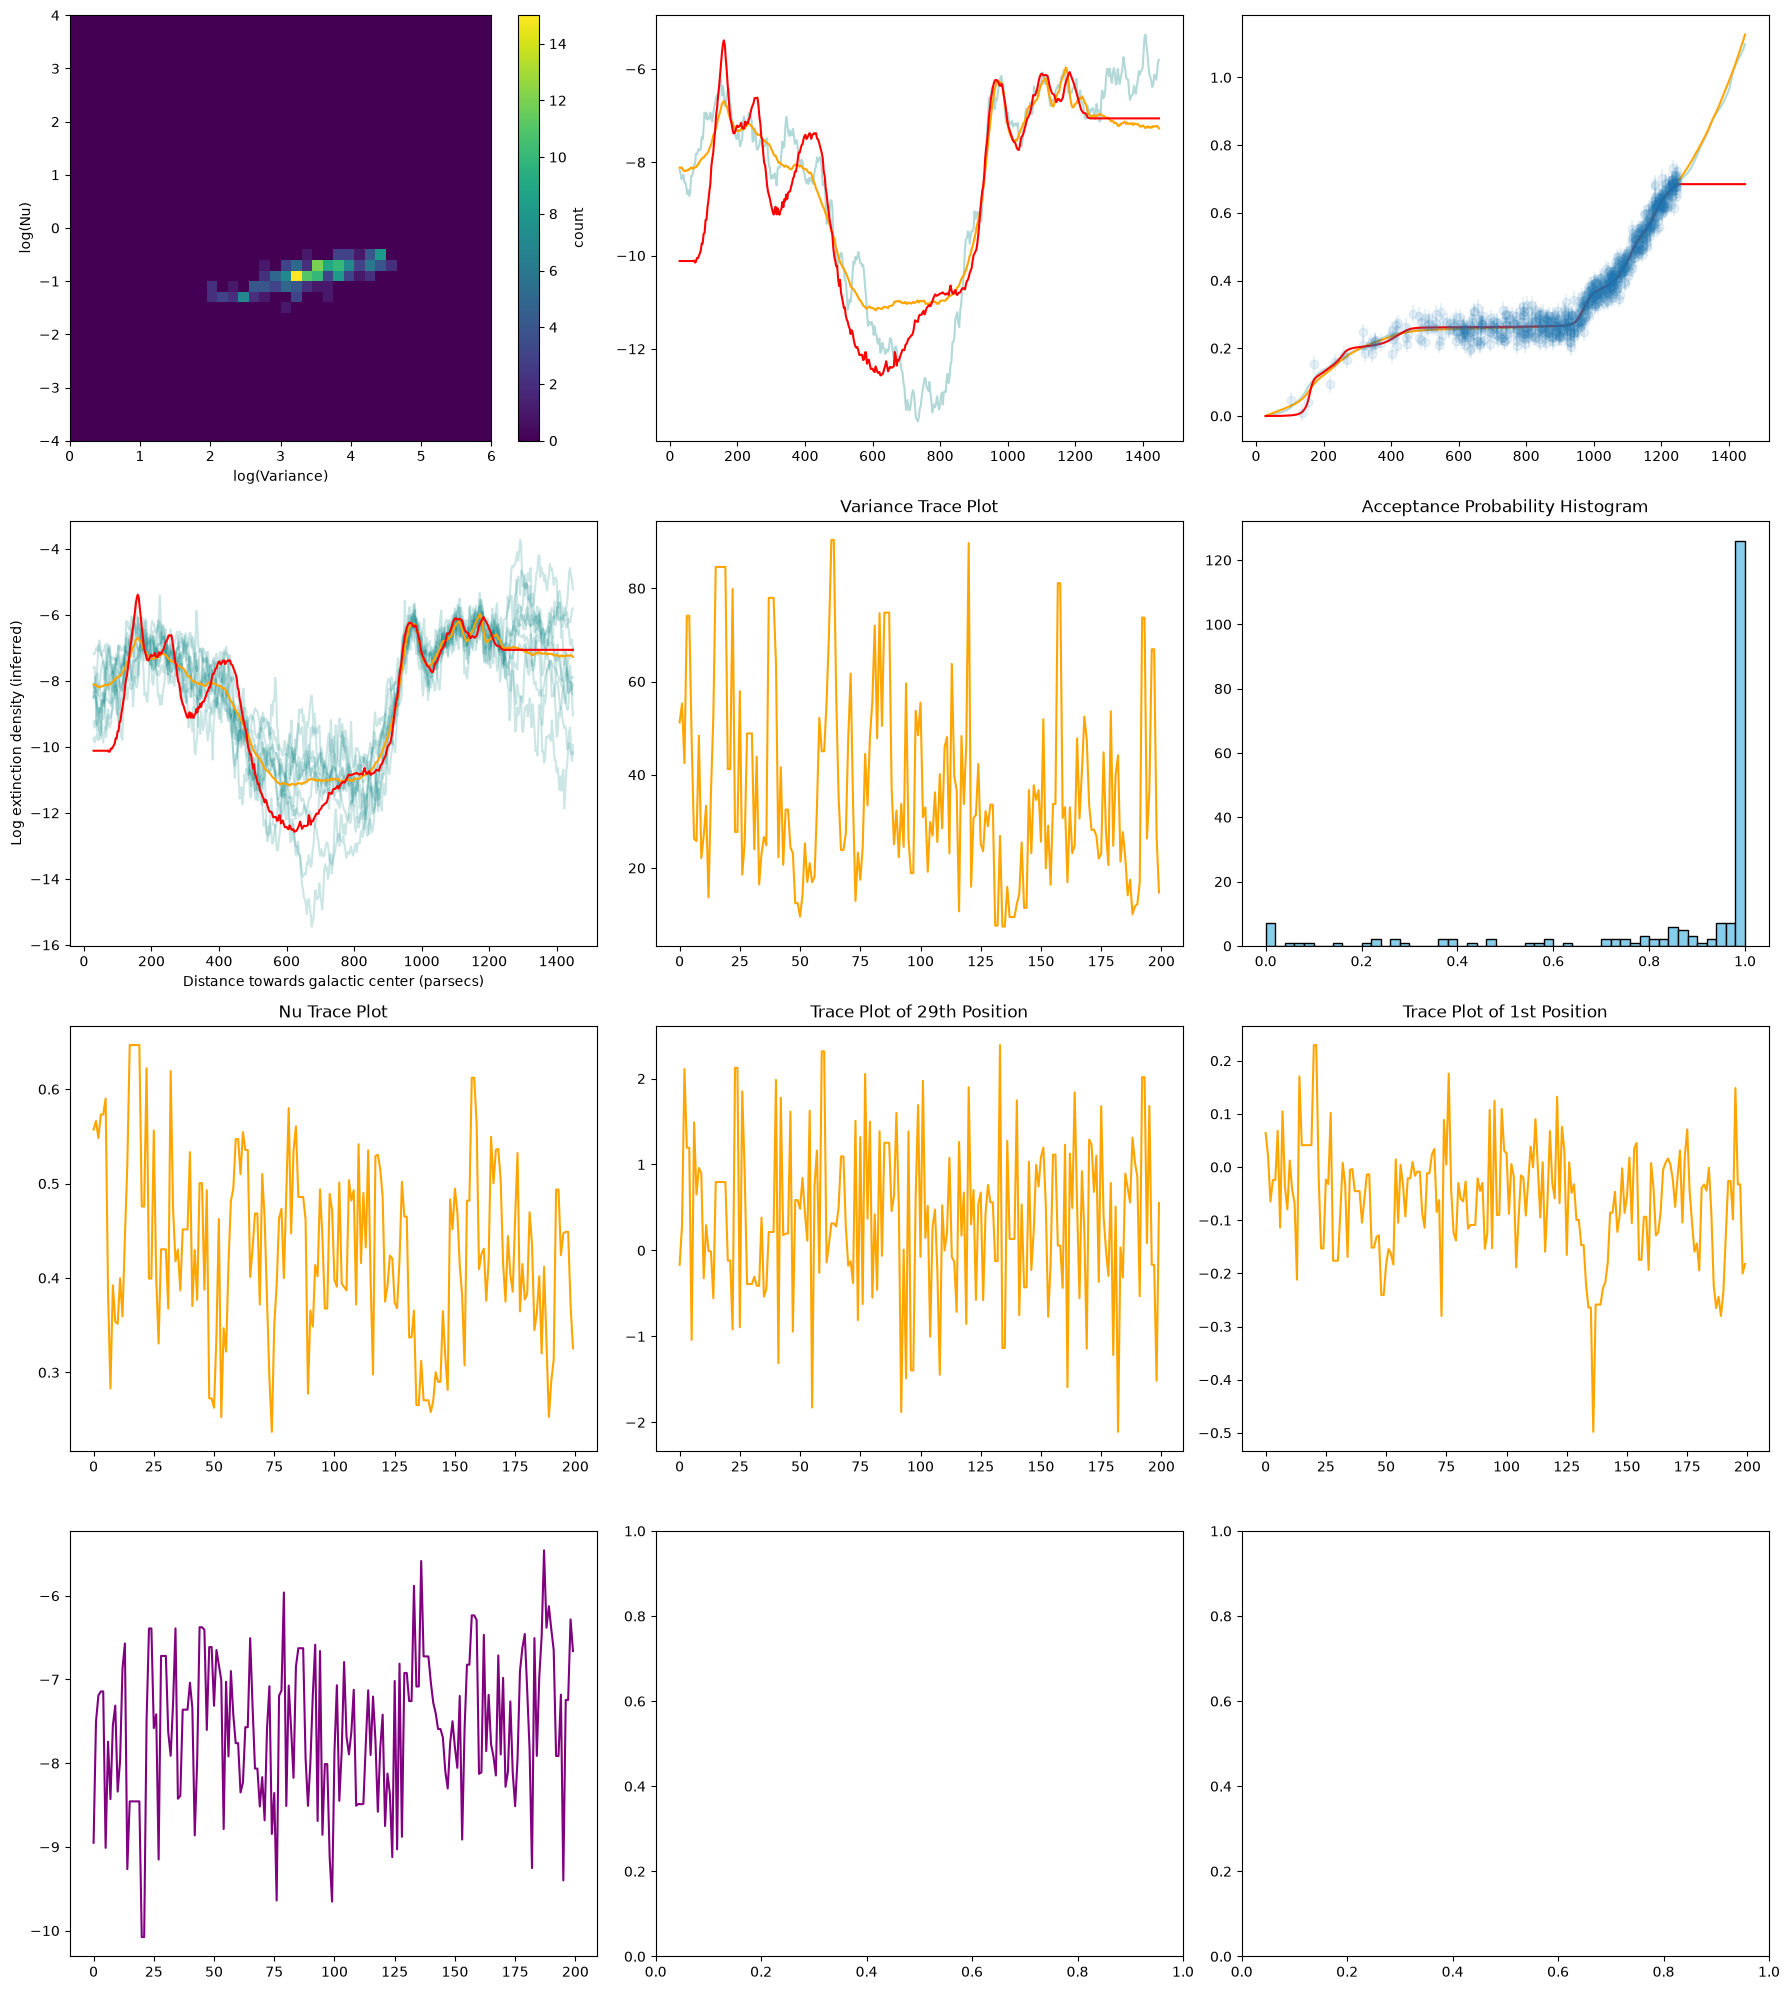

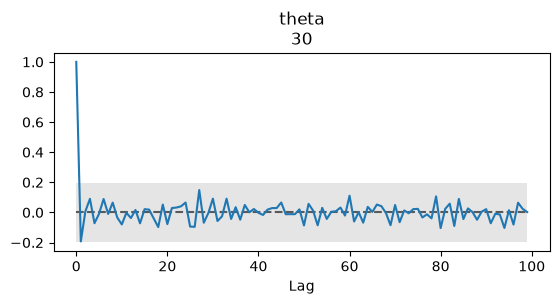

In [258]:
fig, axes = plt.subplots(4, 3, figsize = (18, 20))
for i in range (0, 1):
    axes[0][2].plot(dust_x_linspace, overall_position_arr_exp[500*i, :], color = "teal", alpha = 0.3)
    axes[0][1].plot(dust_x_linspace, overall_position_arr_raw[500*i, :], color = "teal", alpha = 0.3)



print(vars.size)
print(time_arr.size)

# rows you're actually plotting
indices = np.array([10*i for i in range(10)])
mask_indices = np.where(lognus > 0)[0]         
#indices = np.concatenate([indices, mask_indices])

values = np.asarray(jax.vmap(negative_logdensity)(overall_data_arr[indices, :]))   # shape (n_lines,)

# colormap + normalization over the full value range
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=values.min(), vmax=values.max())

for k, i in enumerate(range(indices.size)):
    axes[1][0].plot(
        dust_x_linspace,
        overall_position_arr_raw[indices[i], :],
        color = "teal",
        #color=cmap(norm(values[k])),
        alpha=0.2,
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
#cbar = fig.colorbar(sm, ax=axes[1][0])
#cbar.set_label("Negative logdensity")   

axes[1][0].set_ylabel("Log extinction density (inferred)")
axes[1][0].set_xlabel("Distance towards galactic center (parsecs)")


axes[0][1].plot(dust_x_linspace, mean_position_raw, color = "orange", alpha = 1)
axes[1][0].plot(dust_x_linspace, mean_position_raw, color = "orange", alpha = 1)
axes[0][1].plot(dust_x_linspace, jnp.interp(dust_x_linspace, radial_centers, jnp.log(mean_along_center)), color = "red", alpha = 1)
axes[1][0].plot(dust_x_linspace, jnp.interp(dust_x_linspace, radial_centers, jnp.log(mean_along_center)), color = "red", alpha = 1)
axes[0][2].plot(dust_x_linspace, mean_position_exp, color = "orange", alpha = 1)
axes[0][2].plot(dust_x_linspace, jnp.interp(dust_x_linspace, radial_boundaries, cumulative_integrated_dust), color = "red", alpha = 1)
axes[0][2].errorbar(x_obs, y_obs, yerr=yerr, fmt='o', label='Observations', alpha = 0.1)


number_bins_x = 40
number_bins_y = 40
x_min, x_max = -0, 6
y_min, y_max = -4, 4
dx = (x_max - x_min)/number_bins_x
dy = (y_max - y_min)/number_bins_y

x_centers = (jnp.arange(number_bins_x) + 0.5)*dx + x_min
y_centers = (jnp.arange(number_bins_y) + 0.5)*dy + y_min
x_edges = jnp.arange(number_bins_x + 1)*dx + x_min
y_edges = jnp.arange(number_bins_y + 1)*dy + y_min

H_HMC_samples, _, _ = jnp.histogram2d(logvars, lognus, bins=[x_edges, y_edges])

im2 = axes[0][0].imshow(
    H_HMC_samples.T,
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im2, ax=axes[0][0], label='count')

axes[0][0].set_xlabel("log(Variance)")
axes[0][0].set_ylabel("log(Nu)")
axes[1][1].plot(time_arr, vars, color = "Orange")
axes[1][1].set_title("Variance Trace Plot")
axes[2][0].plot(time_arr, nus, color = "Orange")
axes[2][0].set_title("Nu Trace Plot")
axes[2][1].plot(time_arr, overall_position_arr[:, 28], color = "Orange")
axes[2][1].set_title("Trace Plot of 29th Position")
axes[2][2].plot(time_arr, overall_position_arr[:, 0], color = "Orange")
axes[2][2].set_title("Trace Plot of 1st Position")
axes[1][2].set_title("Acceptance Probability Histogram")
axes[1][2].hist(accept_prob_arr, bins=50, edgecolor='black', color='skyblue')

axes[3][0].plot(time_arr, offsets, color = "Purple")

fig.tight_layout()


posterior_samples = overall_data_arr[np.newaxis, :, :]  # add chain axis -> (1, num_samples, 50)

idata = az.from_dict({"posterior": {"theta": posterior_samples}})

param_index = 30  # first parameter (0-indexed)

az.plot_autocorr(idata, var_names="theta", coords={"theta_dim_0": [param_index]})

ess_all = az.ess(idata, var_names="theta")  # a Dataset, ESS for all 50 parameters at once

# Indices of interest: "first", "second", and "32nd" parameter, 0-indexed as 0, 1, 31
indices_of_interest = {
    "Variance": 0,
    "Nu": 1,
    "29th": 30,
}

for label, idx in indices_of_interest.items():
    ess_val = ess_all["theta"].sel(theta_dim_0=idx).values
    print(f"ESS for {label} parameter (index {idx}): {ess_val}")

print(f"Num integration steps: {num_integration_steps} Step Size: {step_size}")
print(f"Average acceptance probability (acceptance rate) is: {jnp.average(accept_prob_arr)}")
print(f"Num dimensions: {num_dimensions} Num data: {num_data} Total length: {max_distance - min_distance} Noise on each point: {error_bars_on_data} Num HMC trials: {num_overall_steps}")

print(overall_position_arr_raw.shape)

def average_chi_2_based_on_data(x_data, x_field, data, field, inverse_data_cov):
    interp_all_rows = jax.vmap(lambda row: jnp.interp(x_data, x_field, row))
    raw_field_at_data_points = interp_all_rows(field)
    residuals = raw_field_at_data_points - data
    chi_2 = jnp.einsum('ij,jk,ik->i', residuals, inverse_data_cov, residuals)
    return jnp.average(chi_2)/data.size

prior_variances = jnp.diag(cov)[2:]
print(f"Error bars on data: {error_bars_on_data}")
print(f"Logvar prior mean: {logvar_prior_mean} Lognu prior mean: {lognu_prior_mean} Offset prior mean {offset_prior_mean} Initial logvar/lognu/offset values: {initial_logvar}, {initial_lognu}, {initial_offset}")
print(f"Average chi_2 statistic based on the prior: {jnp.average(prior_variances)}")
print(f"Average chi_2 statistic based on the data per data point: {average_chi_2_based_on_data(x_obs, dust_x_linspace, y_obs, overall_position_arr_exp, inv_cov_data_matrix)}")

In [259]:
#np.save("last_position_Gaia_XP_fitting.npy", np.asarray(overall_data_arr[-1]))